In [30]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import os

In [2]:
import seaborn as sns 
sns.set(style="whitegrid")

%config InlineBackend.figure_format = 'retina'
%config Completer.use_jedi = False

In [16]:
np.random.seed(42)               # for reproducibility

In [41]:
tickers = ['AAPL', 'MSFT', 'AMZN']

In [43]:
data_dict = {}
for ticker in tickers:
    path = os.path.join(os.getcwd(), "stocks", ticker+".csv")
    data_dict[ticker] = pd.read_csv(path)

In [52]:
close_prices = pd.DataFrame()

for ticker, df in data_dict.items():
    df['Date'] = pd.to_datetime(df['Date'], format="%d-%m-%Y")
    df = df.set_index('Date')
    close_prices[ticker] = df['Adjusted Close']

In [55]:
prices_df = close_prices.dropna()
prices_df = prices_df["2015-01-01":]

<Figure size 1200x600 with 0 Axes>

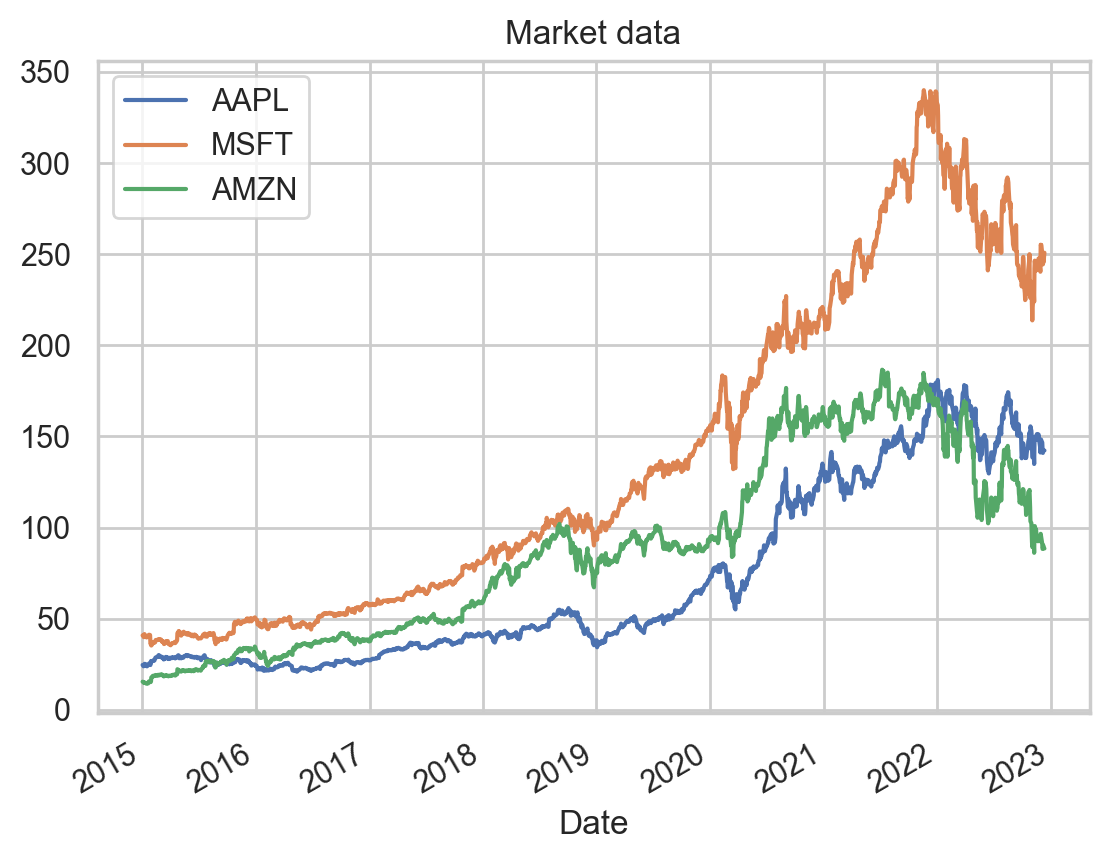

In [66]:
plt.figure(figsize=(12, 6))
prices_df.plot()
plt.title('Market data')
plt.show()

### Real life task: Evaluate the market risk of a small equity portfolio held by a trading desk.


Since yfinance doesn't seem to be working, let's simulate prices using GBM. 
Log returns will follow:

$$\log\left(\frac{S_{t+\Delta t}}{S_t}\right) = \left( \mu - \frac{1}{2} \sigma^2 \right) \Delta t + \sigma \sqrt{\Delta t} \cdot Z_t$$

but using the correated $Z_t$ via the Cholesky decomposition. 

In [25]:
n_assets = 3
n_days = 252                     # 1 year of trading days
dt = 1 / 252  # daily step size

initial_prices = np.array([100, 120, 80])
mu = np.array([0.08, 0.10, 0.06])     # expected annual returns
sigma = np.array([0.2, 0.25, 0.15])   # annual volatilities

# Correlation matrix and Cholesky decomposition
correlation_matrix = np.array([
    [1.0, 0.6, 0.3],
    [0.6, 1.0, 0.4],
    [0.3, 0.4, 1.0]
])
chol_matrix = np.linalg.cholesky(correlation_matrix)


# Simulation:
Z = np.random.normal(0, 1, size=(n_days, n_assets))
correlated_Z = Z @ chol_matrix.T

log_returns = (
    (mu - 0.5 * sigma**2) * dt +
    sigma * np.sqrt(dt) * correlated_Z
)

In [26]:
log_returns_df = pd.DataFrame(log_returns, columns=[f"Asset_{i+1}" for i in range(n_assets)])
prices = pd.DataFrame(np.exp(log_returns_df.cumsum()) * initial_prices, columns=log_returns_df.columns)

<Axes: title={'center': 'Simulated GBM Prices'}>

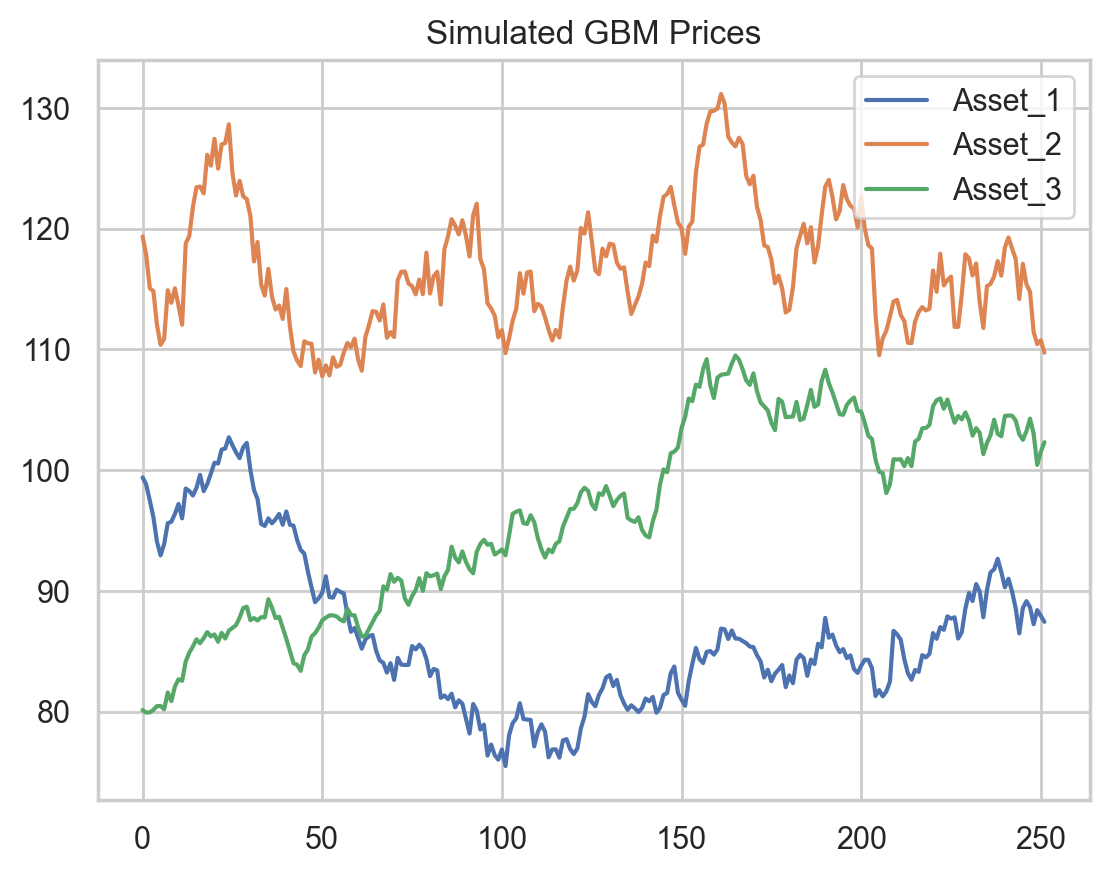

In [27]:
prices.plot(title='Simulated GBM Prices')

Step 1. Define portfolio

Let's use the market data from the csv.. start over with the exercise:

In [67]:
# Step 1
portfolio = {
    'AAPL': {'quantity': 50},
    'MSFT': {'quantity': 30},
    'AMZN': {'quantity': 20}
}

In [68]:
tickers = list(portfolio.keys())

In [60]:
#prices_df = yf.download(tickers, start='2024-01-01', end='2025-04-30')

In [69]:
returns = np.log(prices_df / prices_df.shift(1)).dropna()

<Figure size 1200x600 with 0 Axes>

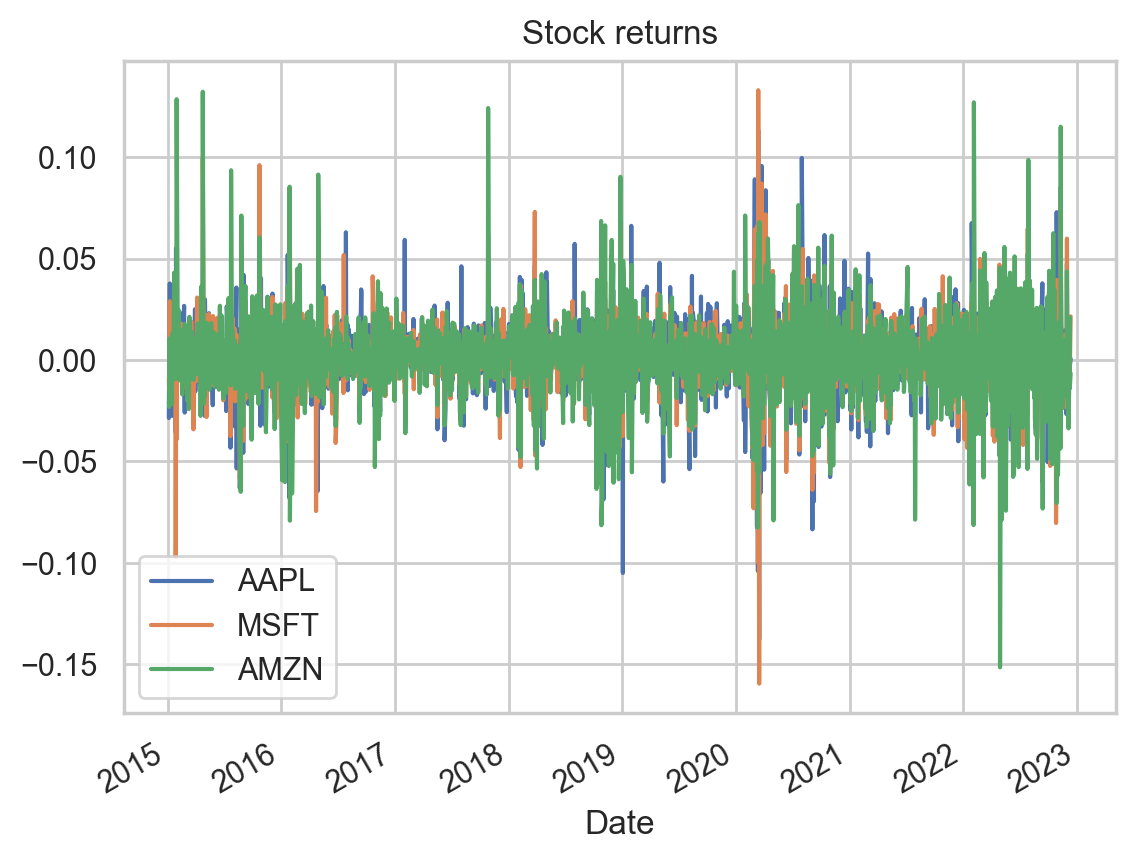

In [72]:
plt.figure(figsize=(12, 6))
returns.plot()
plt.title('Stock returns')
plt.show()

In [75]:
# Step 2: Estimate GBM parameters
mu = returns.mean()
sigma = returns.std()
cov_matrix = returns.cov()

# Step 3: Current prices and position values
last_prices = prices_df.iloc[-1]
for ticker in portfolio:
    portfolio[ticker]['price'] = last_prices[ticker]
    portfolio[ticker]['position_value'] = portfolio[ticker]['quantity'] * last_prices[ticker]

In [99]:
portfolio

{'AAPL': {'quantity': 50,
  'price': 142.24000549316406,
  'position_value': 7112.000274658203},
 'MSFT': {'quantity': 30, 'price': 250.75, 'position_value': 7522.5},
 'AMZN': {'quantity': 20,
  'price': 88.50499725341797,
  'position_value': 1770.0999450683594}}

In [76]:
# Step 4: Monte Carlo GBM Simulation
N = 10000
dt = 1  # 1 day horizon
mean_vector = mu.values
chol_matrix = np.linalg.cholesky(cov_matrix.values)

In [92]:
# Cholesky and simulate
L = np.linalg.cholesky(cov_matrix)
Z = np.random.randn(n_assets, N)
correlated_Z = L @ Z  

In [100]:
# We need to reshape to make the operations compatible
vol = sigma.values.reshape(-1, 1)
drift = (mean_vector - 0.5 * sigma.values**2).reshape(-1, 1) * dt

In [95]:
returns_sim = np.exp(drift + vol * np.sqrt(dt) * correlated_Z)

In [97]:
type(returns_sim)

numpy.ndarray

In [101]:
# Step 5: Simulated portfolio values
initial_values = np.array([portfolio[t]['position_value'] for t in tickers])
simulated_prices = last_prices.values[:, None] * returns_sim
simulated_values = simulated_prices * np.array([portfolio[t]['quantity'] for t in tickers])[:, None]
simulated_portfolio_value = simulated_values.sum(axis=0)

In [104]:
simulated_portfolio_value

array([16415.96017486, 16415.10114553, 16419.31823421, ...,
       16412.854465  , 16410.02242509, 16418.35023775])

Initial Portfolio Value: $16,404.60
1-day 99% VaR: $-0.01


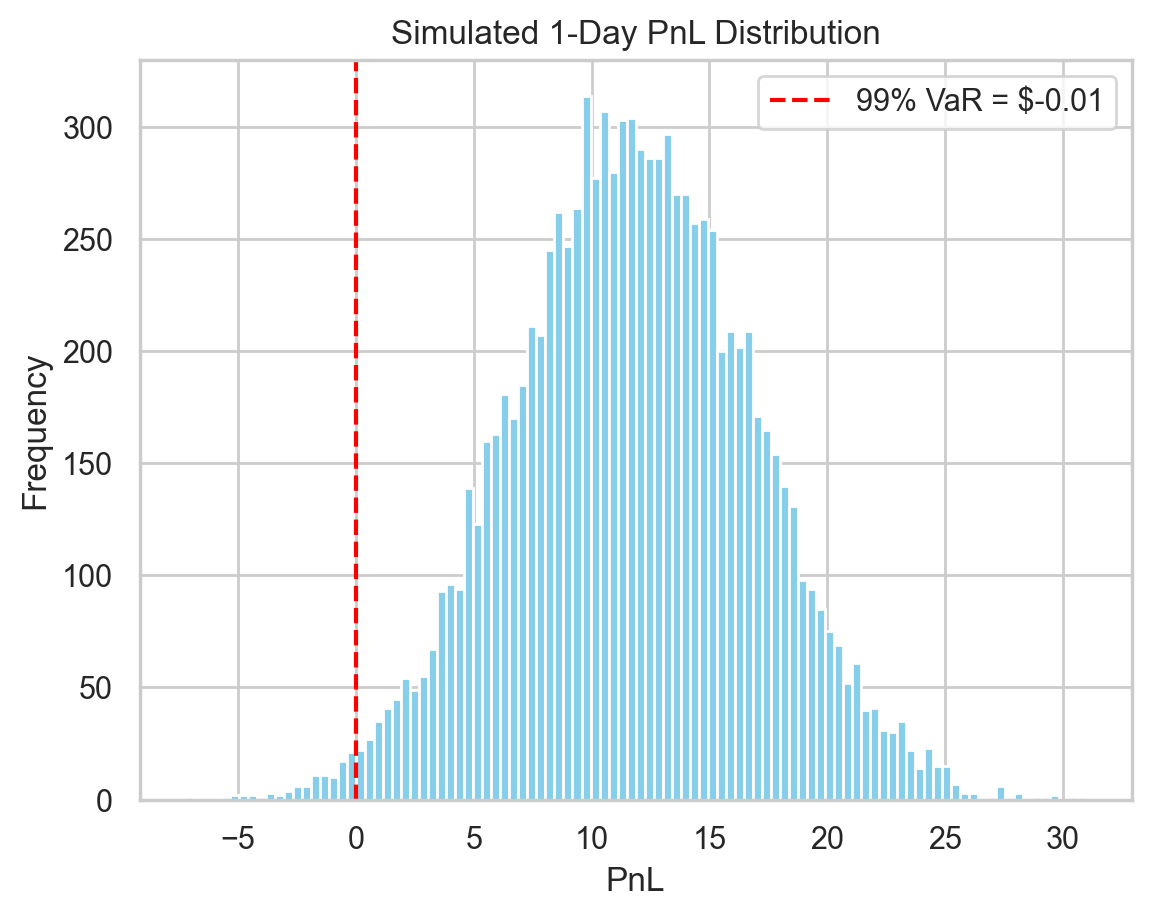

Stress Test Loss: $688.85 (4.20%)


In [105]:
# Step 6: Compute PnL and VaR
initial_portfolio_value = sum(p['position_value'] for p in portfolio.values())
pnl = simulated_portfolio_value - initial_portfolio_value
VaR_99 = -np.percentile(pnl, 1)

print(f"Initial Portfolio Value: ${initial_portfolio_value:,.2f}")
print(f"1-day 99% VaR: ${VaR_99:,.2f}")

# Step 7: Plot PnL distribution
plt.hist(pnl, bins=100, color='skyblue')
plt.axvline(-VaR_99, color='red', linestyle='--', label=f'99% VaR = ${VaR_99:,.2f}')
plt.title('Simulated 1-Day PnL Distribution')
plt.xlabel('PnL')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

# Step 8: Stress test scenario
stress_returns = np.array([-0.05, -0.03, -0.07])
stress_prices = last_prices.values * np.exp(stress_returns)
stress_value = np.dot(stress_prices, [portfolio[t]['quantity'] for t in tickers])
stress_loss = initial_portfolio_value - stress_value
print(f"Stress Test Loss: ${stress_loss:,.2f} ({100*stress_loss/initial_portfolio_value:.2f}%)")

## Adding options.. more complicated example

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
from scipy.stats import norm
import matplotlib.pyplot as plt

# --- 1. Portfolio Setup ---
portfolio = {
    'AAPL': {'quantity': 50},
    'MSFT': {'quantity': 30},
    'AMZN': {'quantity': 20},
    'AAPL_CALL': {'quantity': 10, 'strike': 175, 'expiry_days': 30, 'type': 'call'}
}

tickers = ['AAPL', 'MSFT', 'AMZN']
data = yf.download(tickers, period='1y')['Adj Close']
returns = np.log(data / data.shift(1)).dropna()

mu = returns.mean()
sigma = returns.std()
cov_matrix = returns.cov()

last_prices = data.iloc[-1]
for t in tickers:
    portfolio[t]['price'] = last_prices[t]
    portfolio[t]['position_value'] = portfolio[t]['quantity'] * last_prices[t]

# --- 2. Black-Scholes Formula ---
def bs_call_price(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T)/(sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r*T) * norm.cdf(d2)

# --- 3. Simulation ---
N = 10000
dt = 1/252
T_option = portfolio['AAPL_CALL']['expiry_days'] / 252
r = 0.01  # 1% interest rate
Z = np.random.normal(size=(len(tickers), N))
chol = np.linalg.cholesky(cov_matrix)
correlated_Z = chol @ Z

# Simulate asset prices
returns_sim = np.exp((mu.values - 0.5 * sigma.values**2)*dt + sigma.values*np.sqrt(dt) * correlated_Z)
simulated_prices = last_prices.values[:, None] * returns_sim

# Stock PnL
quantities = np.array([portfolio[t]['quantity'] for t in tickers])
stock_value = (simulated_prices * quantities[:, None]).sum(axis=0)
stock_value0 = sum(p['position_value'] for t, p in portfolio.items() if t in tickers)

# Option PnL
S_aapl_sim = simulated_prices[tickers.index('AAPL')]
sigma_aapl = sigma['AAPL']
call_prices_sim = bs_call_price(S_aapl_sim, portfolio['AAPL_CALL']['strike'], T_option - dt, r, sigma_aapl)
call_price_0 = bs_call_price(last_prices['AAPL'], portfolio['AAPL_CALL']['strike'], T_option, r, sigma_aapl)
option_value = call_prices_sim * portfolio['AAPL_CALL']['quantity']
option_value0 = call_price_0 * portfolio['AAPL_CALL']['quantity']

# Total PnL
total_value = stock_value + option_value
initial_value = stock_value0 + option_value0
pnl = total_value - initial_value

# --- 4. Risk Metrics ---
VaR_99 = -np.percentile(pnl, 1)
CVaR_99 = -pnl[pnl <= -VaR_99].mean()

print(f"Initial Portfolio Value: ${initial_value:,.2f}")
print(f"1-day 99% VaR: ${VaR_99:,.2f}")
print(f"1-day 99% CVaR: ${CVaR_99:,.2f}")

# --- 5. Plot PnL Distribution ---
plt.hist(pnl, bins=100, color='lightblue')
plt.axvline(-VaR_99, color='red', linestyle='--', label=f'VaR 99%: ${VaR_99:,.2f}')
plt.axvline(-CVaR_99, color='darkred', linestyle=':', label=f'CVaR 99%: ${CVaR_99:,.2f}')
plt.title('Simulated Portfolio PnL Distribution')
plt.xlabel('PnL ($)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()